<div style="background-color:#0F172A; border-left:7px solid #00FF99; padding:25px; border-radius:14px; margin:20px 0;">

<h1 style="color:#7CFFB2; font-size:36px; text-shadow:0 0 12px #00FF99; text-align:center;">
🧪 Hands-On Lab: End-to-End Mini-Project
</h1>

<p style="color:#D1FAE5; font-size:18px; text-align:center; line-height:1.8;">
Apply the complete supervised-learning pipeline by building a real machine learning project from dataset selection to final evaluation.
</p>

</div>

<div style="background-color:#1E293B; border-left:7px solid #00FF99; padding:20px; border-radius:14px;">

<h2 style="color:#7CFFB2; font-size:30px; text-shadow:0 0 10px #00FF99;">
🧪 Step 1: Choose Dataset & Define Problem
</h2>

<p style="color:#D1FAE5; font-size:18px; line-height:1.8;">

First, we select a dataset and identify the type of machine learning task.

</p>

<ul style="color:#D1FAE5; font-size:18px; line-height:2;">

<li>
📌 Classification → Predict categories
</li>

<li>
📌 Regression → Predict numerical values
</li>

</ul>

</div>

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd


data = load_breast_cancer()


df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)


df["target"] = data.target


df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

<div style="background-color:#1E293B; border-left:7px solid #00FF99; padding:20px; border-radius:14px;">

<h2 style="color:#7CFFB2; font-size:30px; text-shadow:0 0 10px #00FF99;">
🔍 Step 2: Perform EDA & Preprocessing
</h2>

<p style="color:#D1FAE5; font-size:18px; line-height:1.8;">

In this step, we explore the dataset to understand its structure, identify possible issues, and prepare the data before training the model.

</p>

<ul style="color:#D1FAE5; font-size:18px; line-height:2;">

<li>
📊 Analyze data distributions and statistics.
</li>

<li>
🔎 Check missing values and data problems.
</li>

<li>
🛠️ Apply preprocessing techniques such as scaling.
</li>

<li>
✂️ Split the data before fitting preprocessing steps to avoid data leakage.
</li>

</ul>

</div>

In [3]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [4]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
X = df.drop(
    "target",
    axis=1
)

y = df["target"]

In [6]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

<div style="background-color:#0F172A; border-left:7px solid #00FF99; padding:20px; border-radius:14px;">

<h3 style="color:#7CFFB2; font-size:26px; text-shadow:0 0 10px #00FF99;">
📏 Apply Feature Scaling
</h3>

<p style="color:#D1FAE5; font-size:18px; line-height:1.8;">

Scaling is applied after splitting the data.
The scaler learns only from the training data and then transforms the test data.

</p>

<p style="color:#FFB4C2; font-size:18px;">
⚠️ The test set must never be used during fitting.
</p>

</div>

In [7]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

<div style="background-color:#1E293B; border-left:7px solid #00FF99; padding:20px; border-radius:14px;">

<h2 style="color:#7CFFB2; font-size:30px; text-shadow:0 0 10px #00FF99;">
🤖 Step 3: Train Models & Evaluate Performance
</h2>

<p style="color:#D1FAE5; font-size:18px; line-height:1.8;">

In this step, we train different classification models and compare their performance using suitable evaluation metrics.

</p>

<ul style="color:#D1FAE5; font-size:18px; line-height:2;">

<li>
🤖 Train at least two machine learning models.
</li>

<li>
📊 Evaluate models using appropriate metrics.
</li>

<li>
⚖️ Compare results against a baseline.
</li>

</ul>

</div>

<div style="background-color:#0F172A; border-left:7px solid #00FF99; padding:20px; border-radius:14px;">

<h3 style="color:#7CFFB2; font-size:26px;">
⚖️ Create a Baseline
</h3>

<p style="color:#D1FAE5; font-size:18px;">

A baseline provides a simple reference point.
A useful model should perform better than this minimum level.

</p>

</div>

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score


baseline = DummyClassifier(
    strategy="most_frequent"
)


baseline.fit(
    X_train_scaled,
    y_train
)


baseline_predictions = baseline.predict(
    X_test_scaled
)


baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)


print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.6228070175438597


In [9]:
from sklearn.linear_model import LogisticRegression


log_model = LogisticRegression(
    max_iter=10000
)


log_model.fit(
    X_train_scaled,
    y_train
)


log_predictions = log_model.predict(
    X_test_scaled
)

In [10]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


rf_predictions = rf_model.predict(
    X_test
)

In [11]:
from sklearn.metrics import accuracy_score, f1_score


results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    
    "Accuracy": [
        baseline_accuracy,
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    
    "F1 Score": [
        f1_score(y_test, baseline_predictions),
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions)
    ]
})


results

,Model,Accuracy,F1 Score
0,Baseline,0.622807,0.767568
1,Logistic Regression,0.973684,0.979021
2,Random Forest,0.964912,0.972222


<div style="background-color:#1E293B; border-left:7px solid #00FF99; padding:20px; border-radius:14px;">

<h2 style="color:#7CFFB2; font-size:30px; text-shadow:0 0 10px #00FF99;">
🏆 Step 4: Select the Best Model
</h2>

<p style="color:#D1FAE5; font-size:18px; line-height:1.8;">

After comparing different models, we select the model that provides the best performance based on the chosen evaluation metrics.

</p>

<ul style="color:#D1FAE5; font-size:18px; line-height:2;">

<li>
📊 Compare Accuracy and F1-score results.
</li>

<li>
🏆 Select the model with the best overall performance.
</li>

<li>
📝 Explain why this model is suitable for the problem.
</li>

</ul>

</div>

In [12]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]


best_f1_score = results["F1 Score"].max()


print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1_score)

Best Model: Logistic Regression
Best F1 Score: 0.9790209790209791


<div style="background-color:#0F172A; border-left:7px solid #00FF99; padding:20px; border-radius:14px;">

<h3 style="color:#7CFFB2; font-size:26px;">
📝 Model Selection Explanation
</h3>

<p style="color:#D1FAE5; font-size:18px; line-height:1.8;">

The selected model achieved the highest evaluation score compared with the baseline and other tested models.

The choice was based on performance metrics calculated using unseen test data, which provides a fair evaluation of the model's ability to generalize.

</p>

</div>

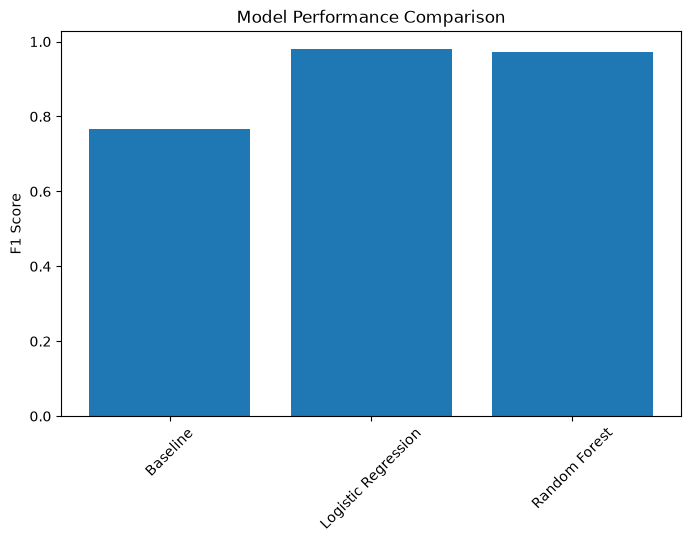

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.xticks(
    rotation=45
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Model Performance Comparison"
)

plt.show()